In [5]:
from cartoblobpy.graph import Graph

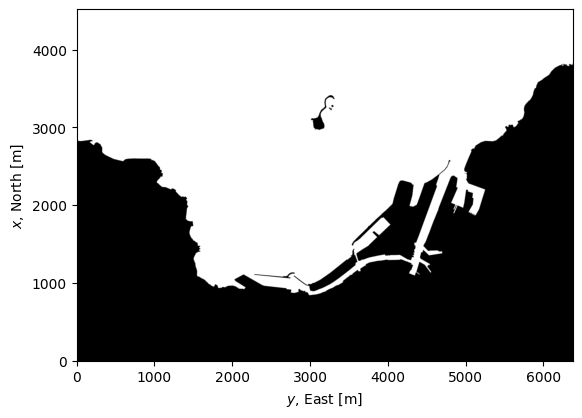

In [6]:
g = Graph()
g.coordinate_frame = "NED"  # or "ENU"
g.load_from_yaml("./map.yaml")
g.inflate_obstacles(radius=0.0, use_world_units=True)  # 5 meters
ax = g.plot(cmap="gray_r")

In [7]:
# Get value from traffic layer at a specific point (world coordinates [x, y])
point = (2500, 2500)
row, col = g.world_to_grid(point).astype(int)

traffic = g.layers["traffic"]
if traffic is None:
    raise ValueError("Layer 'traffic' exists but has no data file.")

h, w = traffic.shape
if not (0 <= row < h and 0 <= col < w):
    raise IndexError(f"Point {point} maps to grid ({row}, {col}) outside layer bounds {(h, w)}")

value = float(traffic[row, col])
print(f"traffic[{row}, {col}] = {value}")

traffic[1250, 1250] = 0.0392156862745098


traffic shape: (2260, 3189)
traffic min/max: 0.000 / 1.000
traffic mean: 0.526
unique values (sample): [0.         0.00392157 0.00784314 0.01176471 0.01568627 0.01960784
 0.02352941 0.02745098 0.03137255 0.03529412]
sample point: [2260. 3188.]
traffic[1130, 1594] = 0.043


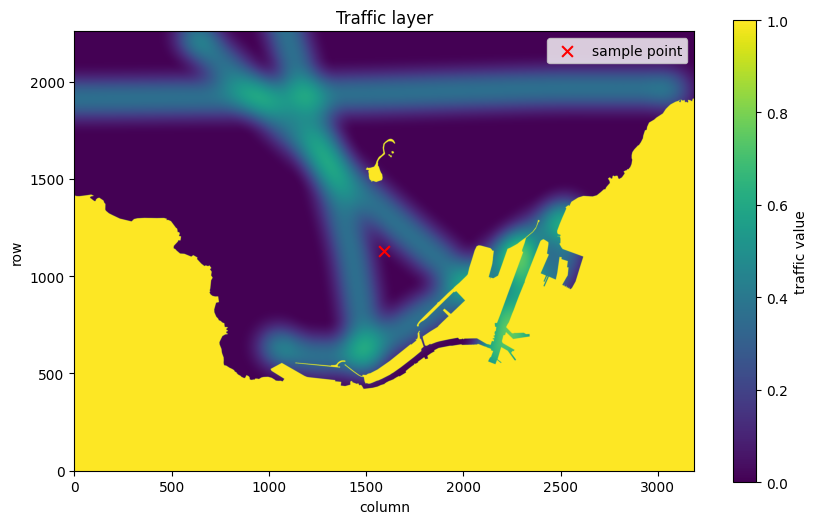

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Traffic layer demo
traffic = g.layers["traffic"]
if traffic is None:
    raise ValueError("Layer 'traffic' exists but has no data file.")

print(f"traffic shape: {traffic.shape}")
print(f"traffic min/max: {traffic.min():.3f} / {traffic.max():.3f}")
print(f"traffic mean: {traffic.mean():.3f}")
print(f"unique values (sample): {np.unique(traffic)[:10]}")

# Sample a point in world coordinates [x, y]
point = g.grid_to_world((traffic.shape[0] // 2, traffic.shape[1] // 2))
row, col = g.world_to_grid(point).astype(int)

if not (0 <= row < traffic.shape[0] and 0 <= col < traffic.shape[1]):
    raise IndexError(f"Point {point} maps to grid ({row}, {col}) outside layer bounds {traffic.shape}")

value = float(traffic[row, col])
print(f"sample point: {point}")
print(f"traffic[{row}, {col}] = {value:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(traffic, cmap="viridis", origin="lower", vmin=0.0, vmax=1.0)
ax.scatter([col], [row], c="red", s=60, marker="x", label="sample point")
ax.set_title("Traffic layer")
ax.set_xlabel("column")
ax.set_ylabel("row")
ax.legend(loc="upper right")
fig.colorbar(im, ax=ax, label="traffic value")
plt.show()